<a href="https://colab.research.google.com/github/keerthu-18-2007/keerthan/blob/main/cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload = files.upload()

Saving cars.csv to cars.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
df=pd.read_csv('cars.csv')
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [ ]:
df.shape

(8128, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB


In [ ]:
df .isnull().mean()

,0
brand,0.0
km_driven,0.0
fuel,0.0
owner,0.0
selling_price,0.0


In [ ]:
df.describe(include='all')

,brand,km_driven,fuel,owner,selling_price
count,8128,8.128000e+03,8128,8128,8.128000e+03
unique,32,NaN,4,5,NaN
top,Maruti,NaN,Diesel,First Owner,NaN
freq,2448,NaN,4402,5289,NaN
mean,NaN,6.981951e+04,NaN,NaN,6.382718e+05
std,NaN,5.655055e+04,NaN,NaN,8.062534e+05
min,NaN,1.000000e+00,NaN,NaN,2.999900e+04
25%,NaN,3.500000e+04,NaN,NaN,2.549990e+05
50%,NaN,6.000000e+04,NaN,NaN,4.500000e+05
75%,NaN,9.800000e+04,NaN,NaN,6.750000e+05


In [ ]:
df.describe(include='object')

,brand,fuel,owner
count,8128,8128,8128
unique,32,4,5
top,Maruti,Diesel,First Owner
freq,2448,4402,5289


In [ ]:
print(df['fuel'].unique())
print(df['selling_price'].unique())
print(df['km_driven'].unique())
print(df['owner'].unique())

['Diesel' 'Petrol' 'LPG' 'CNG']
[  450000   370000   158000   225000   130000   440000    96000    45000
   350000   200000   500000    92000   280000   180000   400000   778000
   150000   680000   174000   950000   525000   600000   575000   275000
   300000   220000   254999   670000    70000   730000   650000   330000
   366000  1149000   425000  2100000   925000   675000   819999   390000
  1500000   700000  1450000  1090000   850000  1650000  1750000  1590000
  1689999  1425000   265000   190000   630000   540000   448000   745000
  1025000   235000  1700000    50000  1200000   610000  2500000   484999
   315000   475000   290000   455000   351000   535000   175000   565000
   120000   725000   185000   615000   270000   625000   866000   375000
   522000   451999   780000   595000  1140000   360000   105000   135000
   690000  3975000  5150000  3200000  4100000  4500000  6000000  3790000
  2150000  5800000  1864999  2700000   795000  3400000  2650000  5850000
   975000   805000 

In [ ]:
df.columns

Index(['brand', 'km_driven', 'fuel', 'owner', 'selling_price'], dtype='object')

/tmp/ipykernel_3711/2599361503.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.selling_price)


<Axes: xlabel='selling_price', ylabel='Density'>

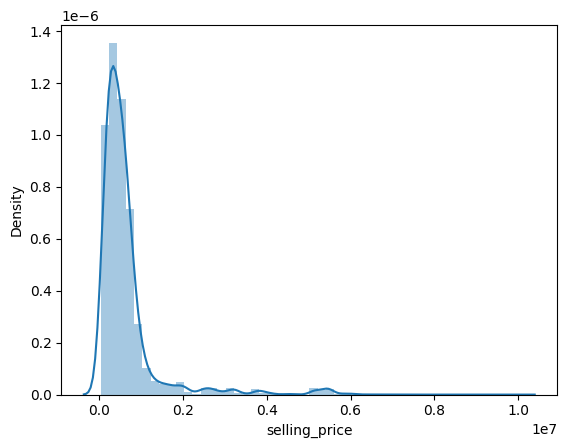

In [ ]:
sns.distplot(df.selling_price)

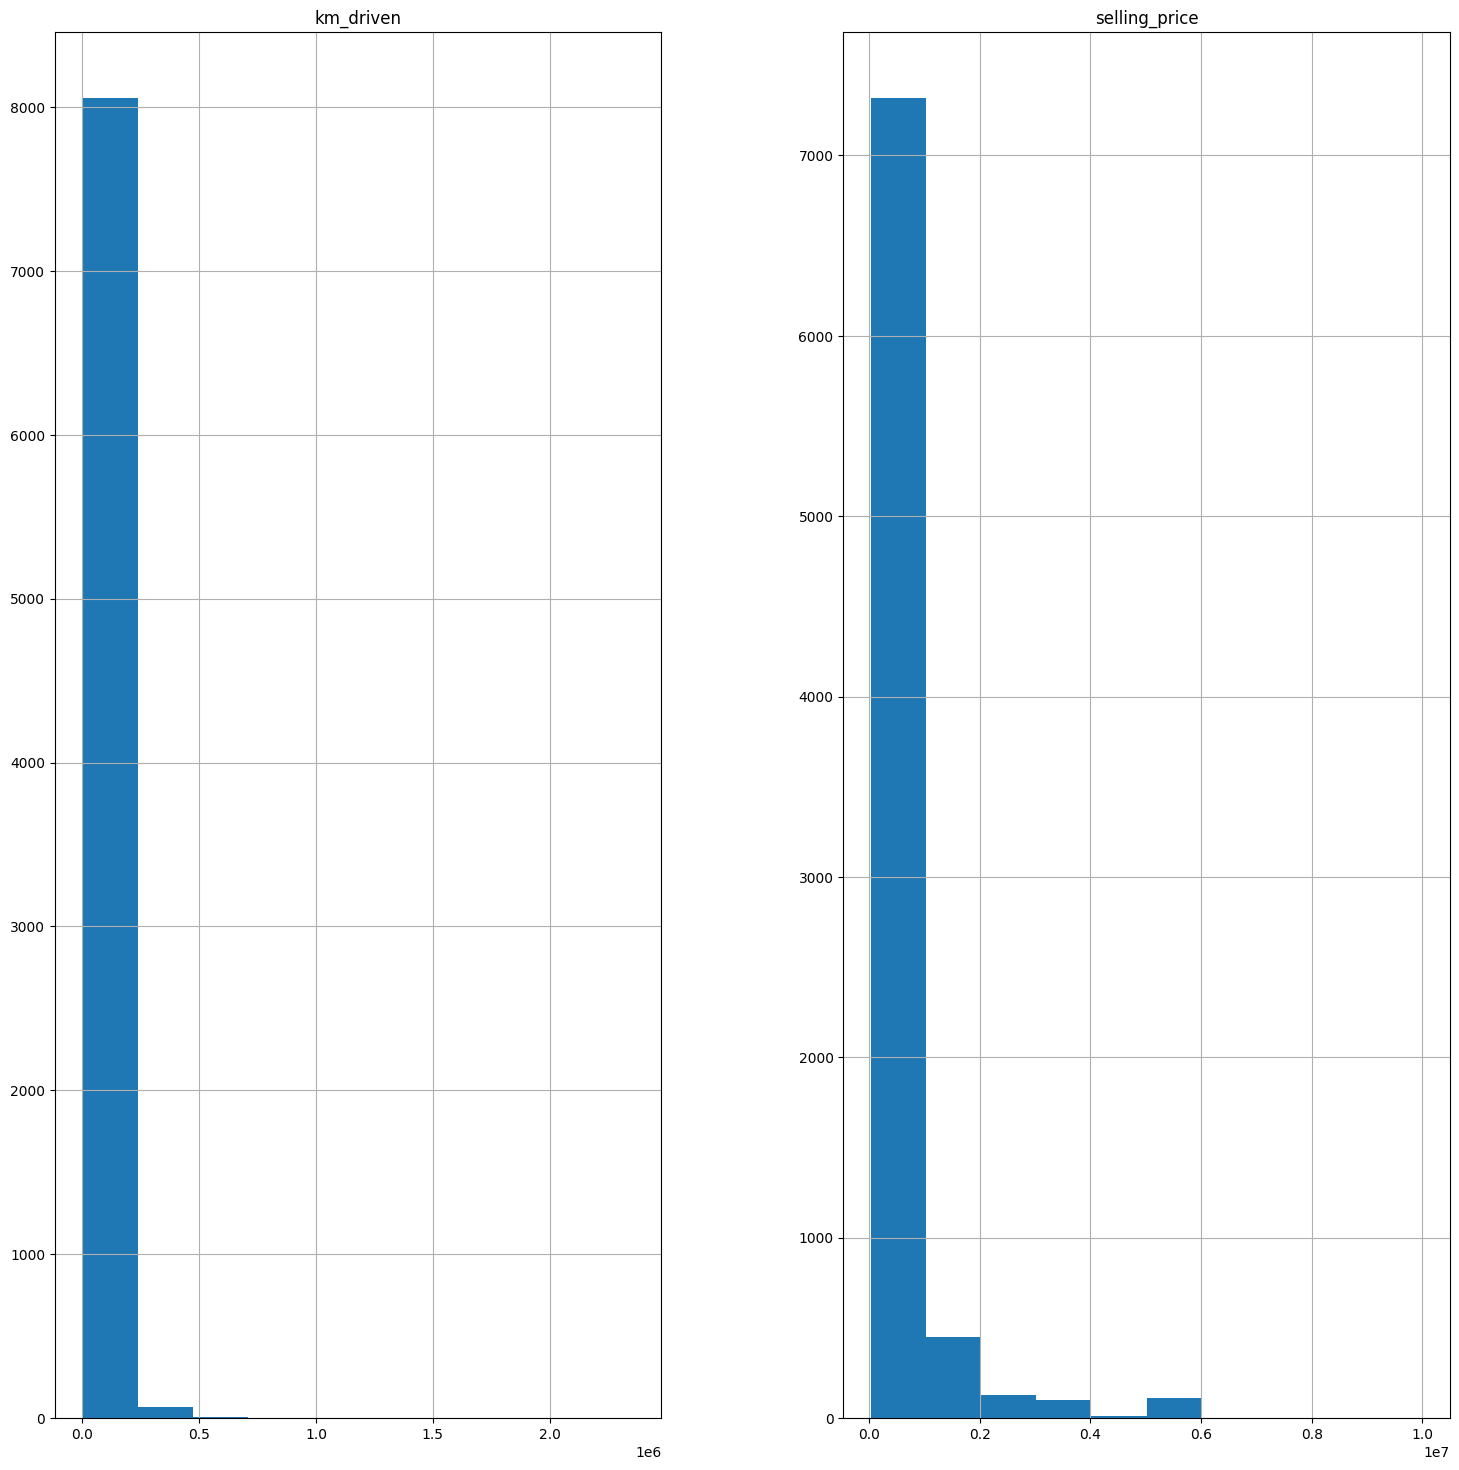

In [ ]:
fig = df.hist(figsize=(18,18))

<Axes: xlabel='fuel', ylabel='selling_price'>

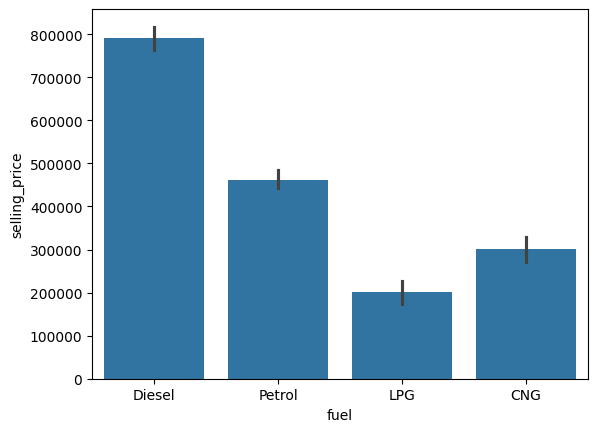

In [ ]:
sns.barplot(x='fuel', y='selling_price', data=df)

<Axes: xlabel='fuel', ylabel='selling_price'>

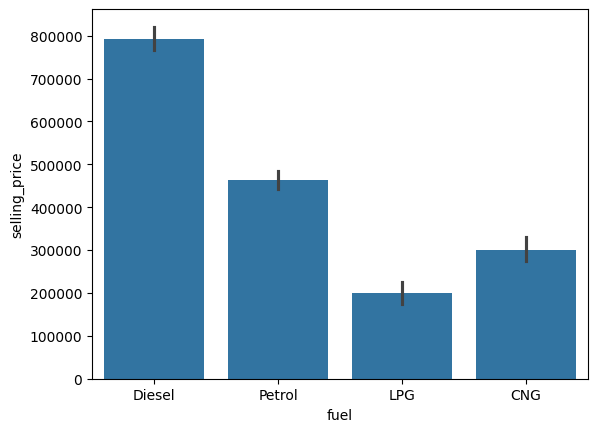

In [ ]:
sns.barplot(x='fuel', y='selling_price', data=df)

<Axes: xlabel='km_driven', ylabel='selling_price'>

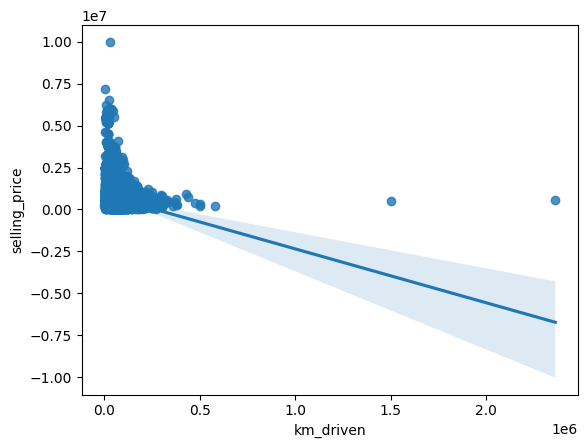

In [ ]:
sns.regplot(x='km_driven', y='selling_price', data=df)

<Axes: xlabel='selling_price', ylabel='km_driven'>

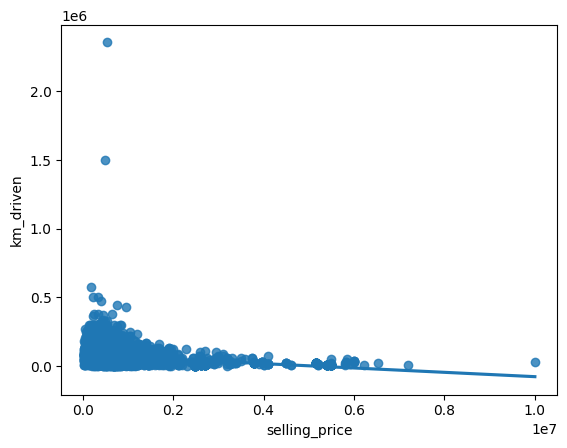

In [ ]:
sns.regplot(x='selling_price', y='km_driven', data=df)

<Axes: xlabel='fuel', ylabel='selling_price'>

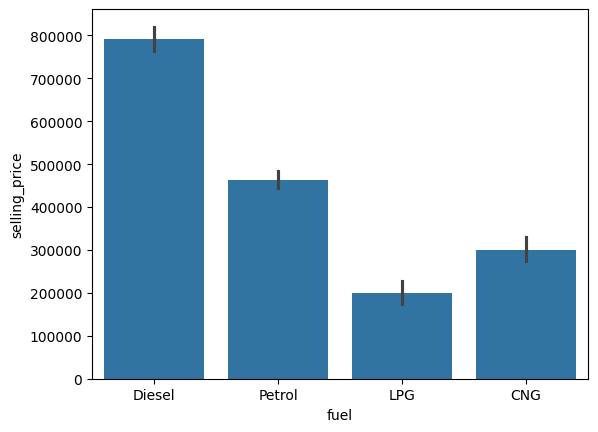

In [ ]:
sns.barplot(x='fuel', y='selling_price', data=df)

<Axes: xlabel='km_driven', ylabel='selling_price'>

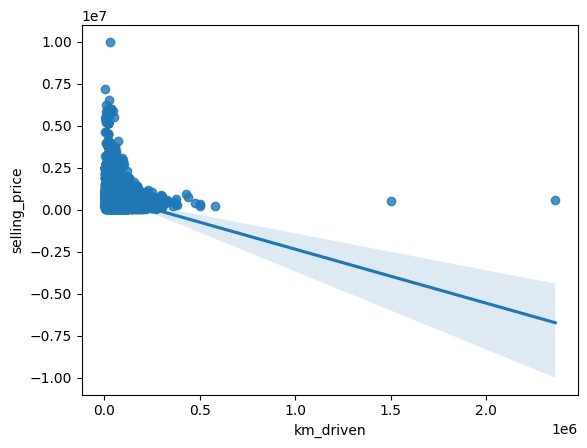

In [ ]:
sns.regplot(x='km_driven', y='selling_price', data=df)

<Axes: xlabel='selling_price', ylabel='km_driven'>

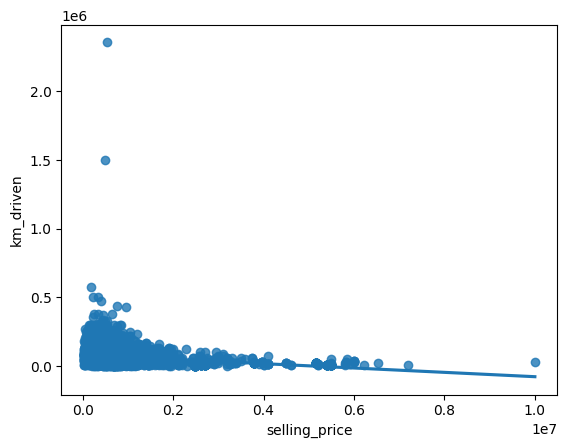

In [ ]:
sns.regplot(x='selling_price', y='km_driven', data=df)

<Axes: xlabel='fuel', ylabel='selling_price'>

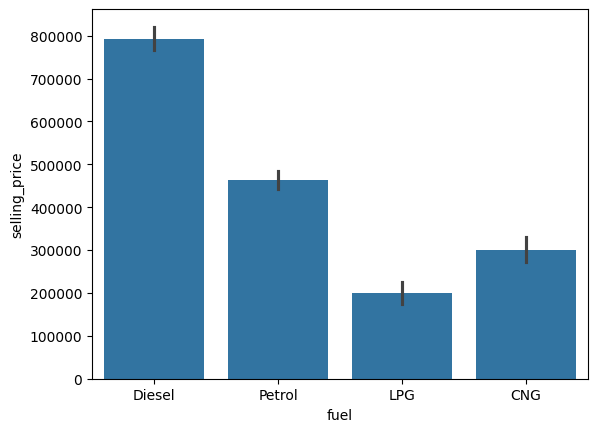

In [ ]:
sns.barplot(x='fuel', y='selling_price', data=df)

<Axes: xlabel='owner', ylabel='selling_price'>

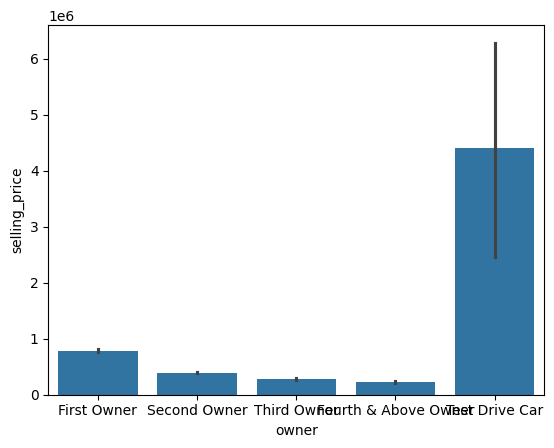

In [ ]:
sns.barplot(x='owner',y='selling_price', data=df)

In [ ]:
def plot_categorical(feature, dataset):
    ax = sns.countplot(y=feature, data=dataset)

    plt.title('Distribution of ' + feature)
    plt.xlabel('Count')

    total = len(dataset[feature])

    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width() / total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y))

    plt.show()


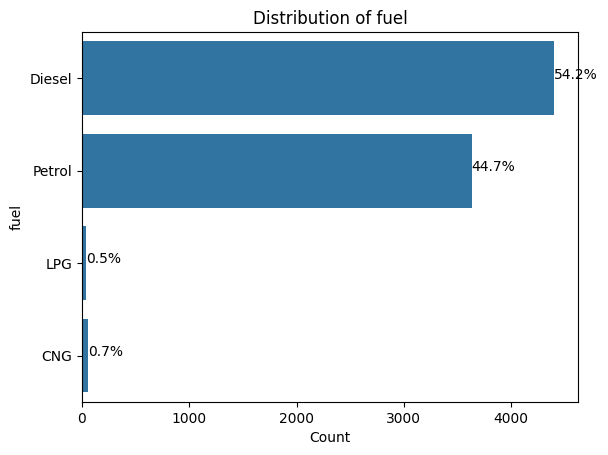

In [ ]:
plot_categorical('fuel',df)

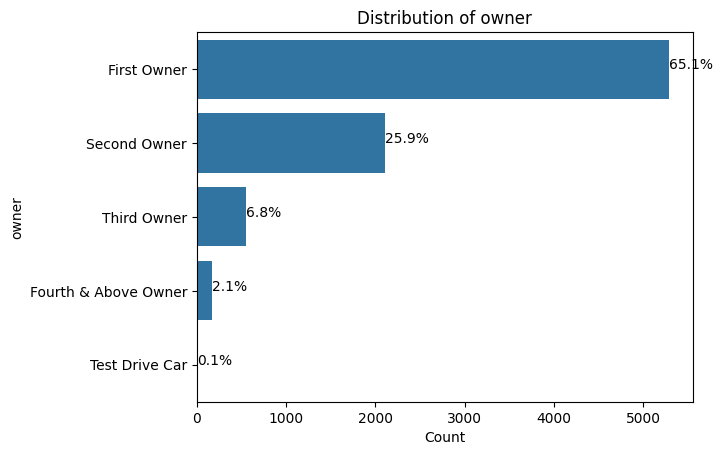

In [ ]:
plot_categorical('owner',df)

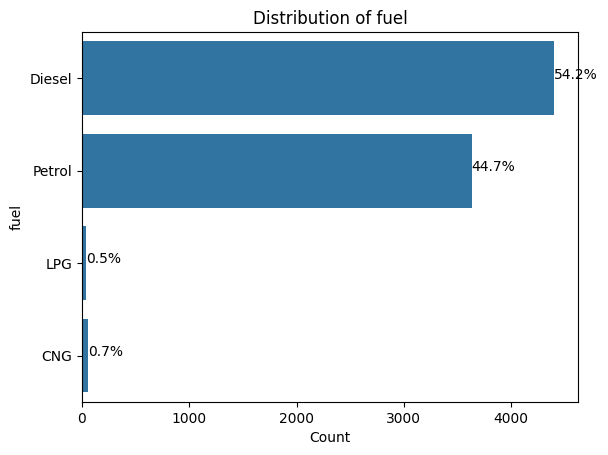

In [ ]:
plot_categorical('fuel',df)